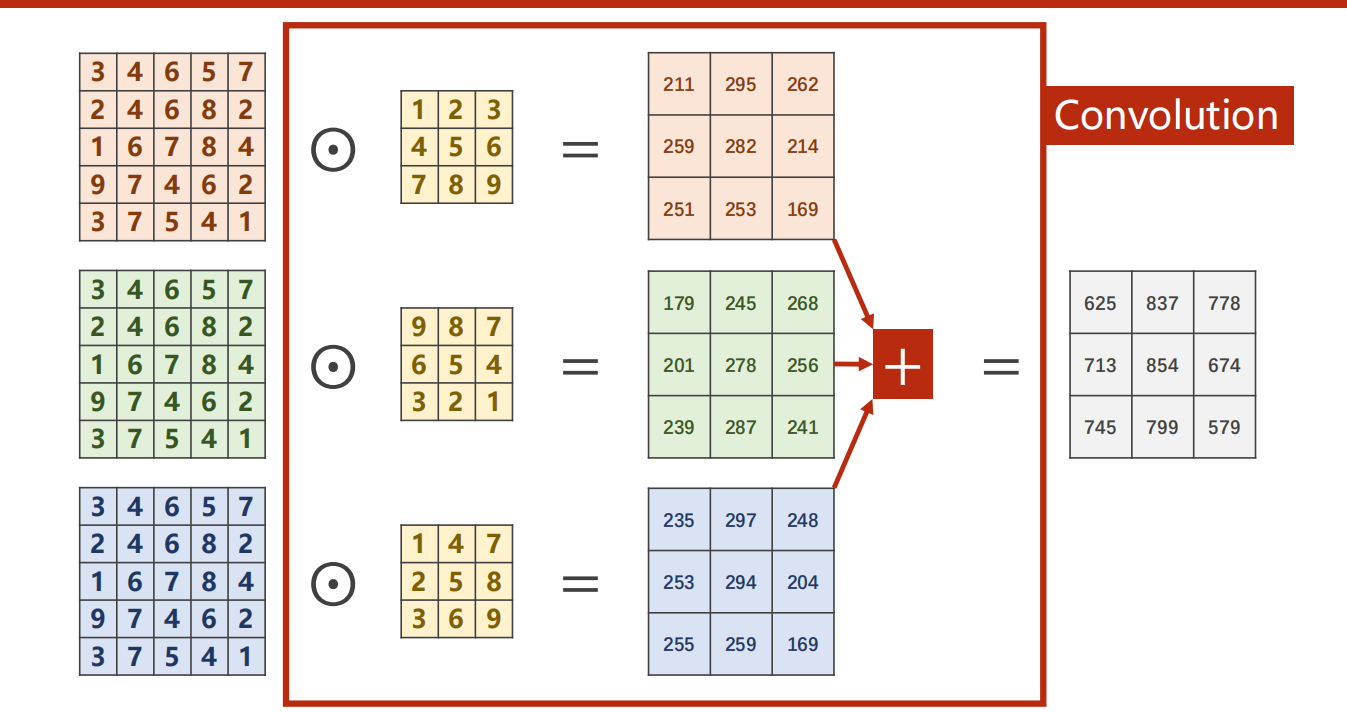


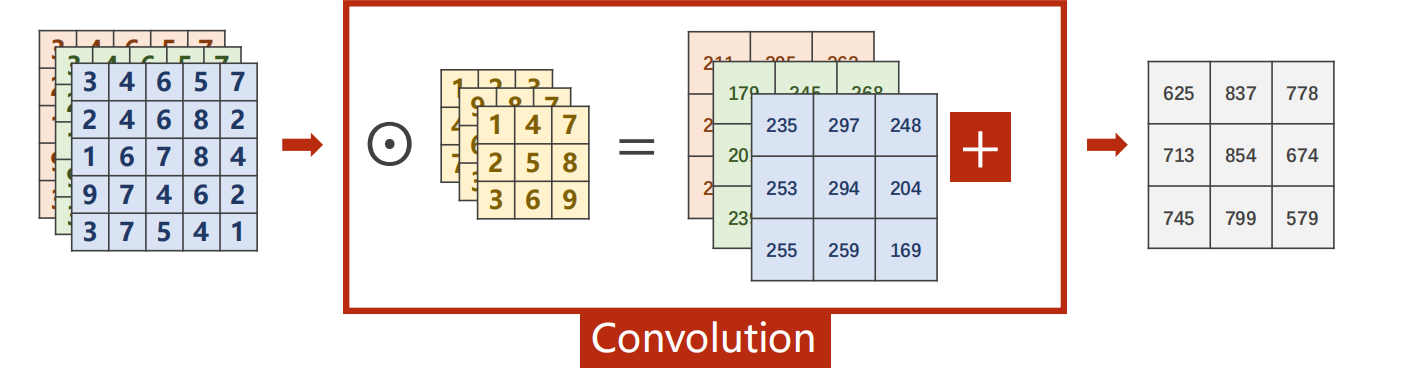


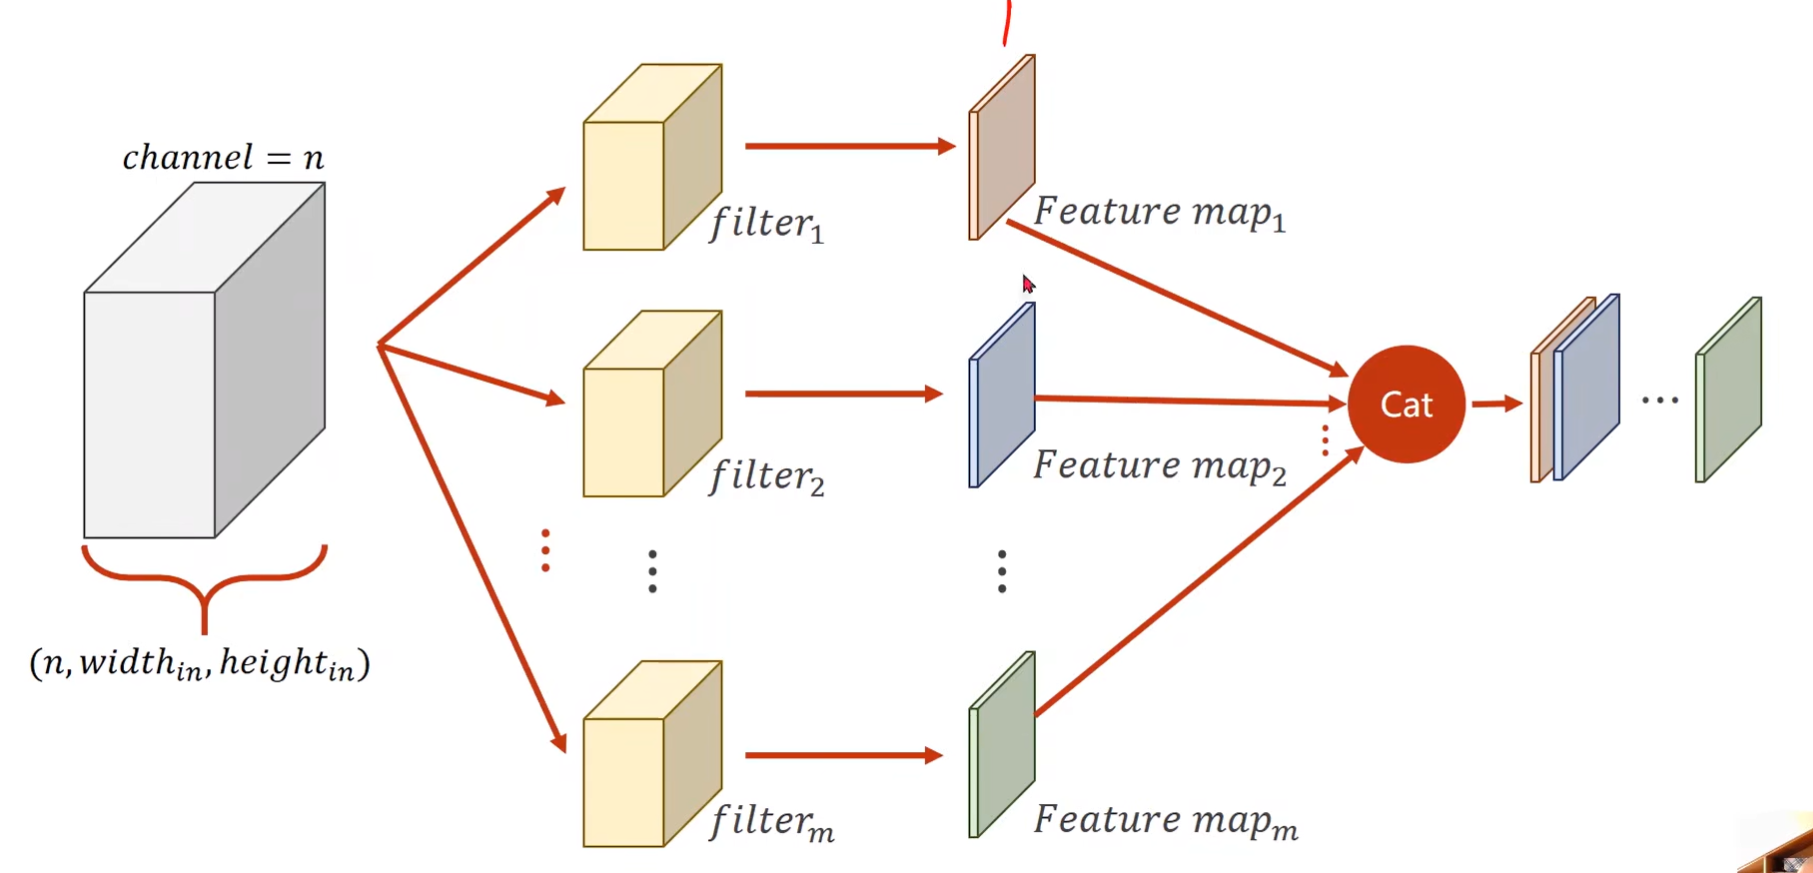
卷积核的通道数和原图片通道数一致，一层卷积核扫描对应一层原图片，扫描过程中填充生成层，具体填充规则为卷积核到达一个位置后，每个卷积核元素和原对应位置元素进行乘积并求和，得到生成层的一个元素，直到填满该生成层，每个层都是如此，最后又生成了和原通道数一样的一个核，这个核要转化为一层，转化规则为：每个位置的所有层对应元素求和，生成最终该位置的元素，所以1个卷积核对应1层，m个卷积核生成通道数为m的最终产物

In [ ]:
import torch
in_channels,out_channels=5,10#输入通道数和输出通道数
height,width=100,100#h对应行，width对应列
kernel_size=3#卷积核边长
batch_size=1#图片数量
#生成一个数据，batch_size张图片，in_channels个通道，每个通道是h*w,也就是生成一个4维tensor
input=torch.randn(batch_size,in_channels,height,width)
#卷积层:这里是2维图片，所以用Con2d,
#定义卷积层我们只需要知道初始通道数，最终通道数，二维对应维度，
#初始的h和w对卷积层的维度，各维度的大小没有影响
#padding=(a,b):上下各加a行，左右各加b列，默认是填充0，对于正方形这里直接整除2就可以使得最终生成的结果的h'=h,w'=w
#stride=(a,b),高度方向每次移动a，宽度方向每次移动b
conv_layer=torch.nn.Conv2d(in_channels,out_channels,kernel_size=(kernel_size,kernel_size))
output=conv_layer(input)
print(input.shape)#torch.Size([1, 5, 100, 100])
print(output.shape)#torch.Size([1, 10, 98, 98])
#.weight指提取出它的权重参数
print(conv_layer.weight.shape)#torch.Size([10, 5, 3, 3])
#这里加assert是因为ide检查这里的时候总是认为这个.bias is None，会提示错误
assert conv_layer.bias is not None
#偏置参数.bias，默认是True,也就是有，每个卷积核都有一个，就是给这个卷积核对应结果的每个元素都加上这个bias
print(conv_layer.bias.shape)#torch.Size([10])




torch.Size([1, 5, 100, 100])
torch.Size([1, 10, 98, 98])
torch.Size([10, 5, 3, 3])
torch.Size([10])


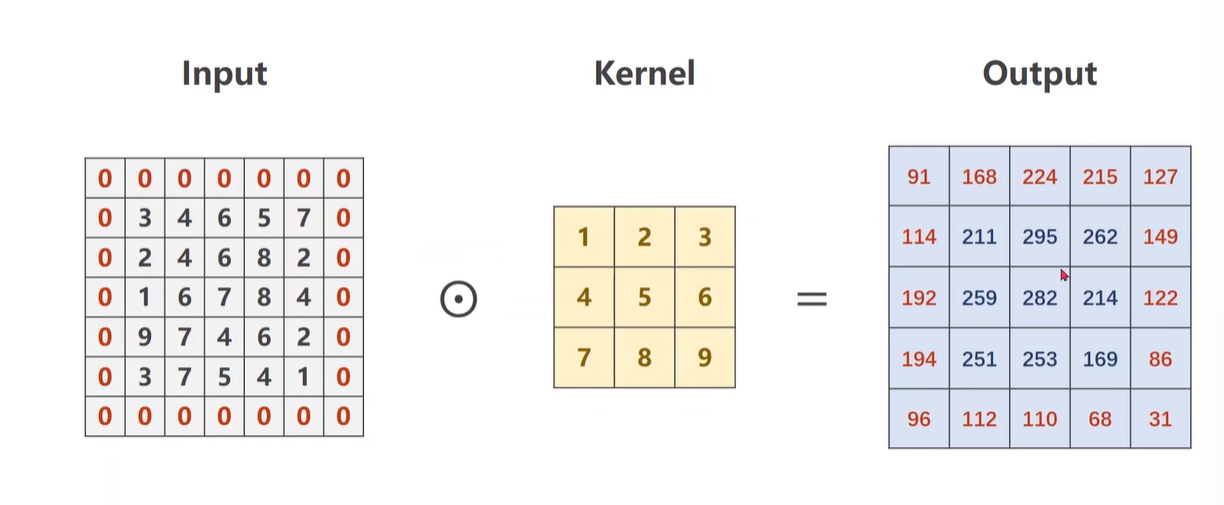
下面模拟这个的计算过程

In [5]:
input= [3,4,6,5,7,
2,4,6,8,2,
1,6,7,8,4,
9,7,4,6,2,
3,7,5,4,1]
input=torch.tensor(input,dtype=torch.float32).view(1,1,5,5)
conv_layer=torch.nn.Conv2d(1,1,kernel_size=(3,3),padding=(1,1),bias=False)
kernel=torch.tensor([1,2,3,4,5,6,7,8,9],dtype=torch.float32).view(1,1,3,3)
with torch.no_grad():
    #自己给卷积层赋权重,.weight是parameter，不能直接赋值，用copy_
    conv_layer.weight.copy_(kernel)
output=conv_layer(input)
print(output)

tensor([[[[ 91., 168., 224., 215., 127.],
          [114., 211., 295., 262., 149.],
          [192., 259., 282., 214., 122.],
          [194., 251., 253., 169.,  86.],
          [ 96., 112., 110.,  68.,  31.]]]], grad_fn=<ConvolutionBackward0>)


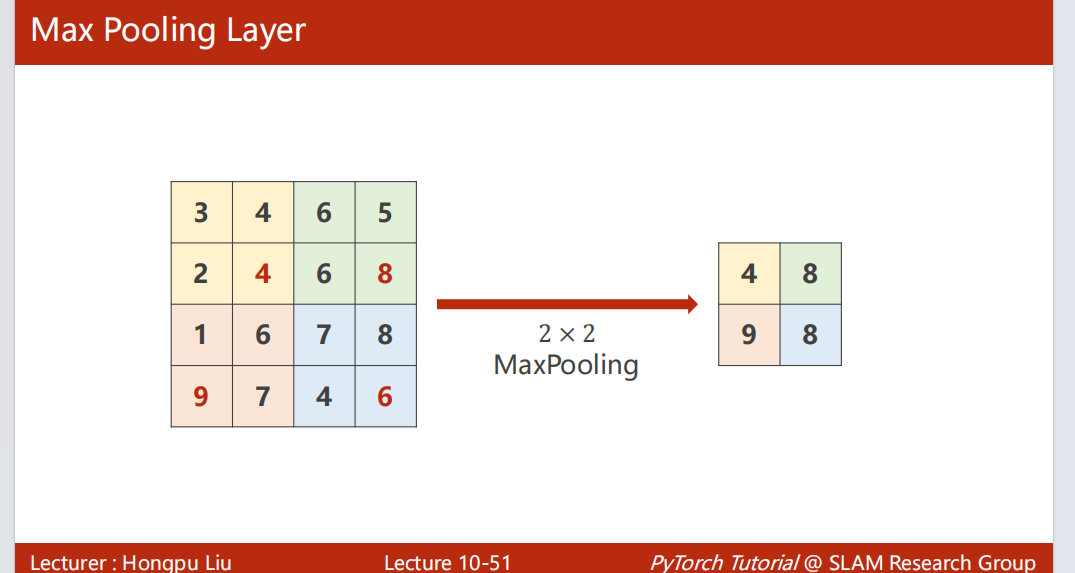
MaxPoolingLayer：最大池化层，取每个窗口的最大值

作用：
- 缩小特征图尺寸，减少后期参数量、计算量
- 把该区域响应最强的特征提取出来，也就是把最有用的信息提取出来


In [8]:
input= [3,4,6,5,
2,4,6,8,
1,6,7,8,
9,7,4,6,
]
input=torch.tensor(input,dtype=torch.float32).view(1,1,4,4)
maxpooling_layer=torch.nn.MaxPool2d(kernel_size=2)#设为2后默认stride也是2,当然可以自己改
print(maxpooling_layer(input))

tensor([[[[4., 8.],
          [9., 8.]]]])


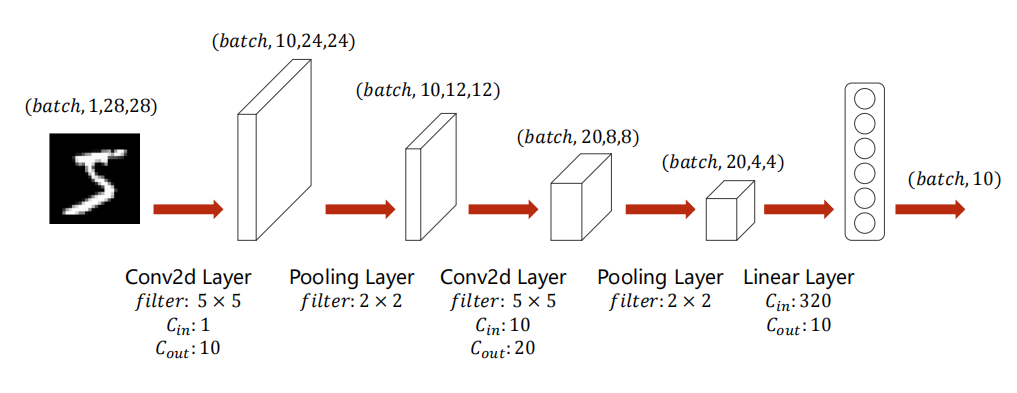

完成这一网络构建

In [ ]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

batch_size = 64
# Compose,依次执行这几个操作
# Nomalize：把数据尽可能处理为均值为0，标准差为1，更利于神经网络训练的稳定性，
# 传元组是因为读入的图片可以有多通道，每个通道站一个位置
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
# 从官网下载数据到本地，train表明是下载训练集还是测试集，transform：对文件进行预处理
train_dataset = datasets.MNIST(
    root="./mnist/", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(
    root="./mnist/", train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)


class Net(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1, 10,3),#5会被看作（5，5）
            torch.nn.ReLU(),#卷积运算本质上还是仿射变换，所以要加入非线性因素
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(10,20,3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(20,25,3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
        )
        self.fc=torch.nn.Sequential(torch.nn.LazyLinear(64),torch.nn.ReLU(),torch.nn.Linear(64,10))


    def forward(self, x):
        x = self.net(x)
        x=x.view(x.size(0),-1)
        return self.fc(x)
model=Net()
device=torch.device('cuda:0'if torch.cuda.is_available()else 'cpu')
model.to(device)
#该函数可以完成
#1.softmax(把最后得到的10个数转为概率，满足每个数>=0且和为1)，
#2.取log
#3.nllloss
criterion=torch.nn.CrossEntropyLoss()
#monetum:能够记忆历史梯度，并自动调节参数更新速度，
# 若某个参数连着朝一个方向更新了好几次，就加快它的更新速度
optimizer=torch.optim.SGD(model.parameters(),lr=0.01,momentum=0.5)
def train():
    for inputs,target in train_loader:
        #模型和输入必须在同一个设备
        inputs,target=inputs.to(device),target.to(device)
        optimizer.zero_grad()
        outputs=model(inputs)
        loss=criterion(outputs,target)
        loss.backward()
        optimizer.step()
def test():
    correct=0
    total=0 
    with torch.no_grad():
        for images,labels in test_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            total+=labels.size(0)
            #_存最大值，predicted存最大值的位置，均为一维，
            # torch.max对每行分别处理
            _,predicted=torch.max(outputs,dim=1)
            #注意：tensor.sum()也是返回一个tensor，这是定义规定的
            #==创建一个bool tensor，元素为每个比较结果，bool型，sum按照0/1统计
            correct+=(predicted==labels).sum().item()
    print('accuracy on test set:%.2f %%'%(100*correct/total))
for epoch in range(10):
    train()
    test()
#两套conv2d+relu+maxpool
# accuracy on test set:96.84 %
# accuracy on test set:97.91 %
# accuracy on test set:98.26 %
# accuracy on test set:98.49 %
# accuracy on test set:98.57 %
# accuracy on test set:98.33 %
# accuracy on test set:98.61 %
# accuracy on test set:98.72 %
# accuracy on test set:98.69 %
# accuracy on test set:98.67 %
#当前是三套

accuracy on test set:90.73 %
accuracy on test set:94.08 %
accuracy on test set:95.06 %
accuracy on test set:96.91 %
accuracy on test set:97.01 %
accuracy on test set:97.45 %
accuracy on test set:97.46 %
accuracy on test set:97.61 %
accuracy on test set:97.50 %
accuracy on test set:97.32 %


三套比两套差的原因：这里三套后最后一次maxpool把二维尺寸压成了1*1，把空间信息基本压没了